In [1]:
import sys
import os
import json
sys.path.append(os.path.abspath('..'))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

#import preprocessing functions
from src.preprocessing import preprocess

#import random forest specific functions
from src.random_forest import train_random_forest, test_random_forest

### This notebook will examine the preformance of random forest models on the ADMET dataset

In [2]:
# -- Raw training data
clean_train = preprocess(pd.read_csv("../data/raw/train_raw.csv") )

# -- Raw testing data
clean_test = preprocess(pd.read_csv("../data/raw/test_raw.csv"))

KeyboardInterrupt: 

In [2]:
# -- Load Training and Testing Dataframes
clean_train = pd.read_csv('clean_train.csv',index_col=0,low_memory=False)
clean_test = pd.read_csv('clean_test.csv',index_col=0,low_memory=False)

In [3]:
# --Defining targets and model/scores dictionaries
training_features = ['MolWt', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'LogP'] + \
                    [col for col in clean_train.columns if col.startswith('fps_')]
targets = []
for col in clean_train.columns:
    if col in training_features:
        continue
    elif 'fps' in col: 
        continue
    elif col.startswith('log_'):
        targets.append(col)
    elif clean_train[col].dtype in ['float64', 'int64']:
        # Only add raw column if no log version exists
        log_version = f'log_{col}'
        if log_version not in clean_train.columns:
            targets.append(col)
            
rf_models = {}
rf_scores = {}
rf_data = {}

#### Load Trained Models into dictionary, since random forest models were trained using External Resources

In [3]:
import joblib
import os

rf_models = {}

model_dir = '../models/random_forest'
for filename in os.listdir(model_dir):
    if filename.endswith('.pkl'):
        target = filename.replace('rf_', '').replace('.pkl', '')
        rf_models[target] = joblib.load(os.path.join(model_dir, filename))


with open('../models/random_forest/rf_scores.json', 'r') as f:
    rf_scores = {target: np.array(scores) for target, scores in json.load(f).items()}

rf_data = {}
for target in rf_scores.keys():
    y = np.load(f'../models/random_forest/y_{target}.npy', allow_pickle=True)
    y_pred_cv = np.load(f'../models/random_forest/y_pred_cv_{target}.npy', allow_pickle=True)
    rf_data[target] = (None, y, y_pred_cv)

In [6]:
# -- Training
for target in targets:
    model, scores, X, y, y_pred_cv = train_random_forest(clean_train, target)
    rf_models[target] = model
    rf_scores[target] = scores
    rf_data[target] = (X, y, y_pred_cv)

KeyboardInterrupt: 

#### Output the importance of each feature to the prediction -- higher number means more useful for predictions

In [10]:
for target, model in rf_models.items():
    print(f"\n--- Summary for: {target} ---")
    
    summary_df = pd.DataFrame({
        'Feature': model.feature_names_in_,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False).head(15)
    
    print(summary_df.to_string(index=False))
    
    mean_score = rf_scores[target].mean()
    print(f"Mean CV R2: {mean_score:.4f}")


--- Summary for: KSOL ---
 Feature  Importance
 fps_659    0.101328
    LogP    0.067724
   MolWt    0.042711
    TPSA    0.029587
  fps_13    0.025719
 fps_407    0.017220
 fps_904    0.014344
 fps_197    0.012074
 fps_383    0.009987
  fps_60    0.008470
  fps_80    0.008319
RotBonds    0.007898
 fps_598    0.007859
 fps_593    0.007374
     HBD    0.007039
Mean CV R2: 0.1132

--- Summary for: LogD ---
 Feature  Importance
    LogP    0.375135
 fps_197    0.042058
 fps_659    0.041293
 fps_561    0.032925
   MolWt    0.022220
    TPSA    0.019595
     HBD    0.011608
 fps_284    0.010661
 fps_383    0.008814
 fps_305    0.008625
 fps_980    0.008168
fps_1019    0.007905
RotBonds    0.006366
 fps_563    0.006361
fps_1023    0.006252
Mean CV R2: 0.5702

--- Summary for: log_HLM CLint ---
 Feature  Importance
    LogP    0.086265
 fps_142    0.051526
   MolWt    0.050220
 fps_741    0.035796
    TPSA    0.026204
 fps_504    0.020280
 fps_506    0.016625
 fps_562    0.013571
 fps_398   

#### Plot 10-Fold CV R2 scores

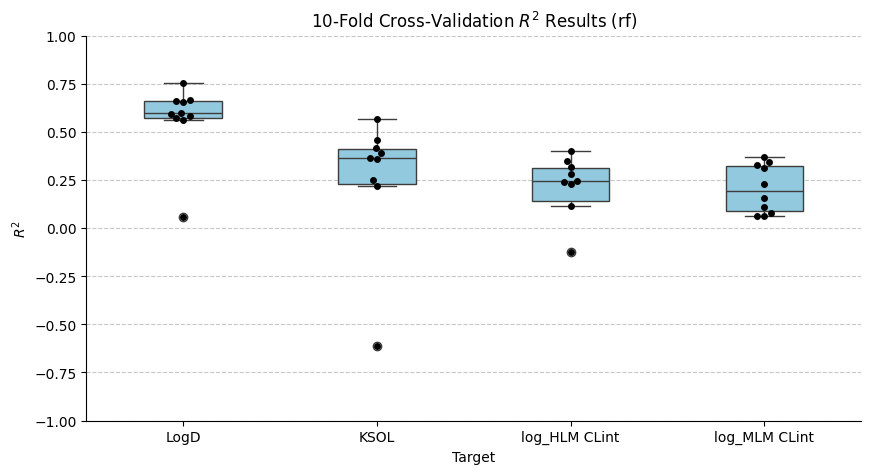

In [5]:
scores_df_rf = pd.DataFrame(rf_scores)

plt.figure(figsize=(10, 5))
sns.boxplot(data=scores_df_rf, color='skyblue', width=0.4)
sns.swarmplot(data=scores_df_rf, color='black')

plt.title(r'10-Fold Cross-Validation $R^2$ Results (rf)')
plt.ylabel(r'$R^2$')
plt.ylim(-1,1)
plt.xlabel('Target')
plt.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine()
plt.show()

#### Plot the residuals to check for any correlations -- ideally there should be none

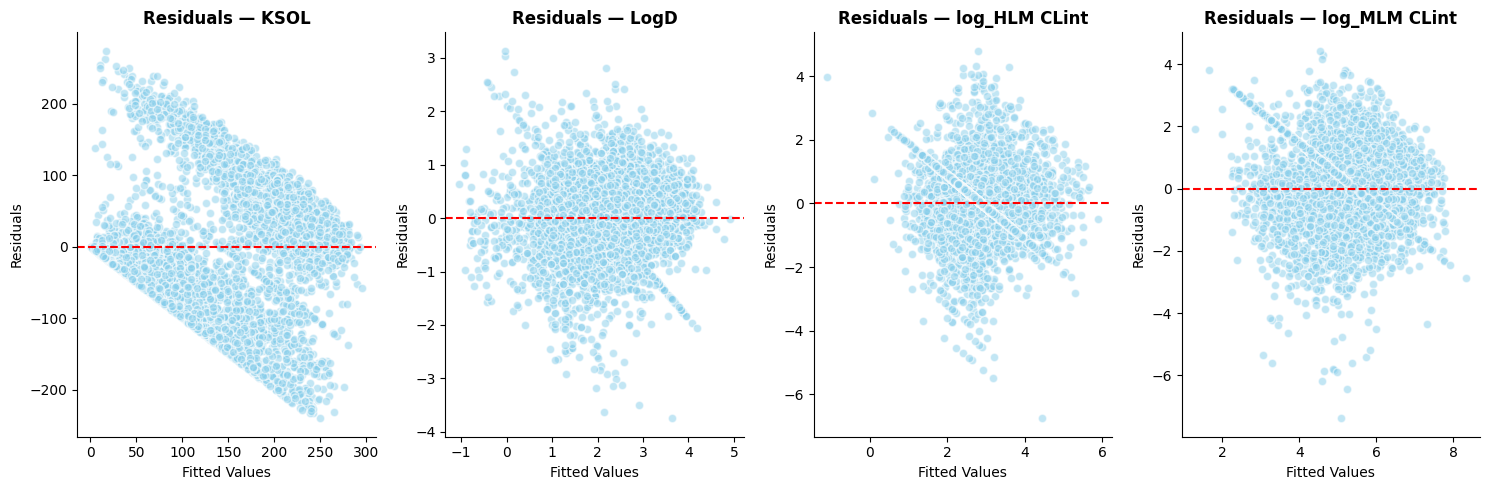

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for ax, (target, model) in zip(axes, rf_models.items()):
    X, y, y_pred_cv = rf_data[target]
    residuals = y - y_pred_cv
    ax.scatter(y_pred_cv, residuals, alpha=0.5, color='skyblue', edgecolors='white')
    ax.axhline(y=0, color='red', linestyle='--')
    ax.set_title(f'Residuals — {target}', fontweight='bold')
    ax.set_xlabel('Fitted Values')
    ax.set_ylabel('Residuals')
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

Similar heteroskedasticity as was seen with linear regression/lasso models

In [7]:
rf_pred = {} #dictionary to hold the predictions from each model
rf_resid = {} #dictionary to hold the residuals for later convience
for target in rf_models.keys():
    #predict each target using its respective trained lasso regression model and store results in the rf_pred dictionary
    rf_pred[target] = test_random_forest(clean_test, rf_models[target])

    residuals = rf_pred[target] - clean_test[target] #calcualte residuals
    rf_resid[target] = residuals #store resids

KSOL | $R^2 = 0.709$
############################################################
KSOL Evaluation Table
           MSE       RMSE        MAE        R2
0  3856.275019  62.098913  41.718308  0.709413
LogD | $R^2 = 0.834$
############################################################
LogD Evaluation Table
        MSE     RMSE       MAE        R2
0  0.212079  0.46052  0.275625  0.833851
log_HLM CLint | $R^2 = 0.764$
############################################################
log_HLM CLint Evaluation Table
        MSE      RMSE       MAE        R2
0  0.295785  0.543861  0.352496  0.763653
log_MLM CLint | $R^2 = 0.733$
############################################################
log_MLM CLint Evaluation Table
        MSE      RMSE       MAE        R2
0  0.502352  0.708768  0.467975  0.732578


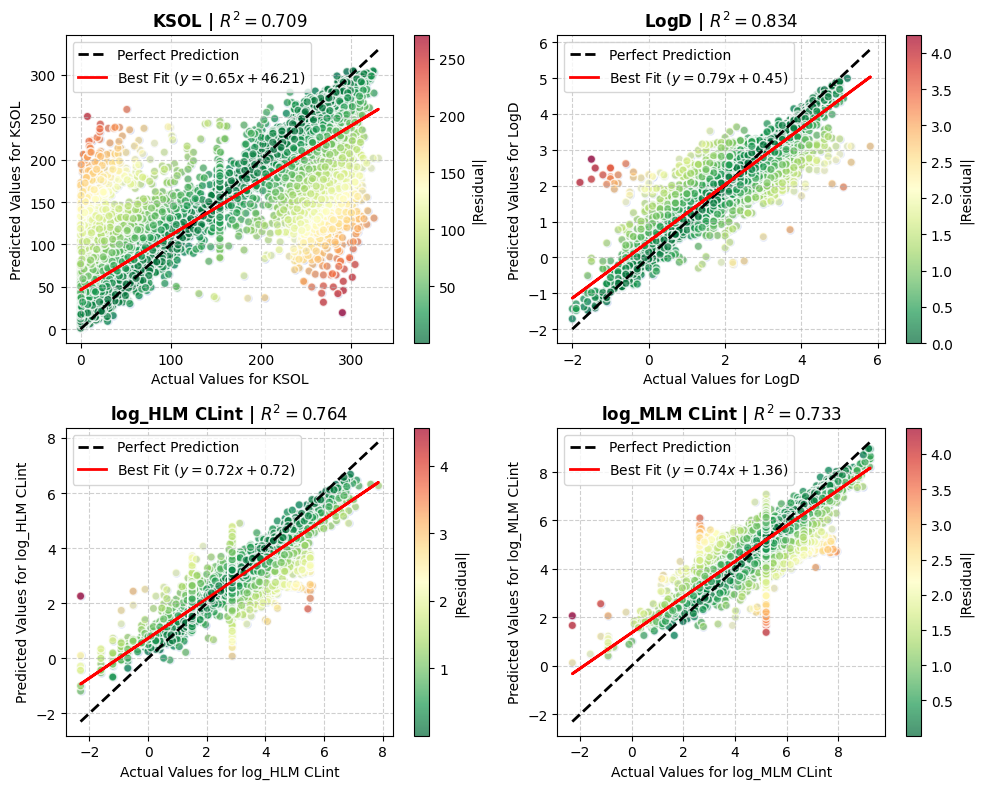

In [8]:
from src.evaluate import eval_model

# Plot test results for each Lasso model
fig, axs = plt.subplots(2, 2, figsize=(10, 8)) #Set axis
axs_flat = axs.flatten()  #flatten to use in loop

for i, target in enumerate(rf_pred.keys()):
    ax = axs_flat[i]
    y_pred = rf_pred[target]
    y_real = clean_test[target]
    mse, rmse, mae, r2 = eval_model(y_real, y_pred) #calculate evaluation metrics
    m, b = np.polyfit(y_real, y_pred, 1)
    ax.scatter(y_real, y_pred, alpha=0.5, color='royalblue', edgecolors='w')
    residuals = abs(rf_resid[target])
    scatter = ax.scatter(y_real, y_pred, c=residuals, cmap='RdYlGn_r', #colour the residuals based on proximity to perfect prediction
                     alpha=0.7, edgecolors='w')
    plt.colorbar(scatter, ax=ax, label='|Residual|')
    min_val = min(min(y_real), min(y_pred))
    max_val = max(max(y_real), max(y_pred))
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Prediction') #line representing perfect prediction
    ax.plot(y_real, m * y_real + b, color='red', lw=2, label=f'Best Fit ($y={m:.2f}x{b:+.2f}$)') #line of best fit

    ax.set_xlabel(f'Actual Values for {target}')
    ax.set_ylabel(f'Predicted Values for {target}')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()
    ax.set_title(f'{target} | $R^2 = {r2:.3f}$', fontsize=12, fontweight='bold')

    print(f'{target} | $R^2 = {r2:.3f}$')

    ##########Build Evaluation Table###########
    evaluation_results = {'MSE' : mse,
                          'RMSE': rmse,
                          'MAE' : mae,
                          'R2'  : r2 }
    eval_table = pd.DataFrame(evaluation_results,index=[0])
    print('#'*60)
    print(f'{target} Evaluation Table')
    print(eval_table)

plt.tight_layout()
plt.show()

Random forest outpreforms baseline for all targets, with KSOL being the weakest. KSOL also has extreme MAE and RMSE due to high range in solubility values in the data. KSOL also  exhibits regression toward the mean at extreme values, underestimating high solubility compounds and overestimating low solubility compounds. 

Similar to baseline models, LogD shows the best results with the lowest error metrics.

# Save Models

In [ ]:
import joblib

os.makedirs('../models', exist_ok=True)

# Save random forest models
for target, model in rf_models.items():
    joblib.dump(model, f'../models/random_forest/rf_{target}.pkl')